In [5]:
from datetime import datetime
import os
import pickle
import numpy as np
import pandas as pd

import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from generation.utils import plot_iv_surface
from generation.surface_generation import generate_surfaces, SimulationConfig
from models.framework import DeepONet, MLP

# ============================================================
# 1️⃣ Generate synthetic Rough Bergomi IV surfaces
# ============================================================

cfg = SimulationConfig(M=50000, n=500, T_max=2.0, S0=1.0, G=1)
surfaces = generate_surfaces(
    num_sets=1,
    forward_curves_per_set=10,
    cfg=cfg,
    seed=4235,
    randomize_grid=False,
)


# SAVE_ROOT = "data/fixed_longrun"
# surfaces = []

# # List and sort all batch files (batch_0000.pkl, batch_0001.pkl, ...)
# batch_files = sorted([
#     f for f in os.listdir(SAVE_ROOT)
#     if f.startswith("fixed_batch_") and f.endswith(".pkl")
# ])

# # print(f"Found {len(batch_files)} batch files.")

# for fname in batch_files:
#     path = os.path.join(SAVE_ROOT, fname)
#     try:
#         with open(path, "rb") as f:
#             data = pickle.load(f)
#             # If each file stores {"surfaces": [...]} dicts:
#             if isinstance(data, dict) and "surfaces" in data:
#                 surfaces.extend(data["surfaces"])
#             # Or if it’s already a list:
#             elif isinstance(data, list):
#                 surfaces.extend(data)
#             else:
#                 print(f"⚠️ Unrecognized format in {fname}")
#         print(f"Loaded {fname}")
#     except Exception as e:
#         print(f"❌ Error loading {fname}: {e}")

# print(f"\n✅ Total surfaces loaded: {len(surfaces)}")


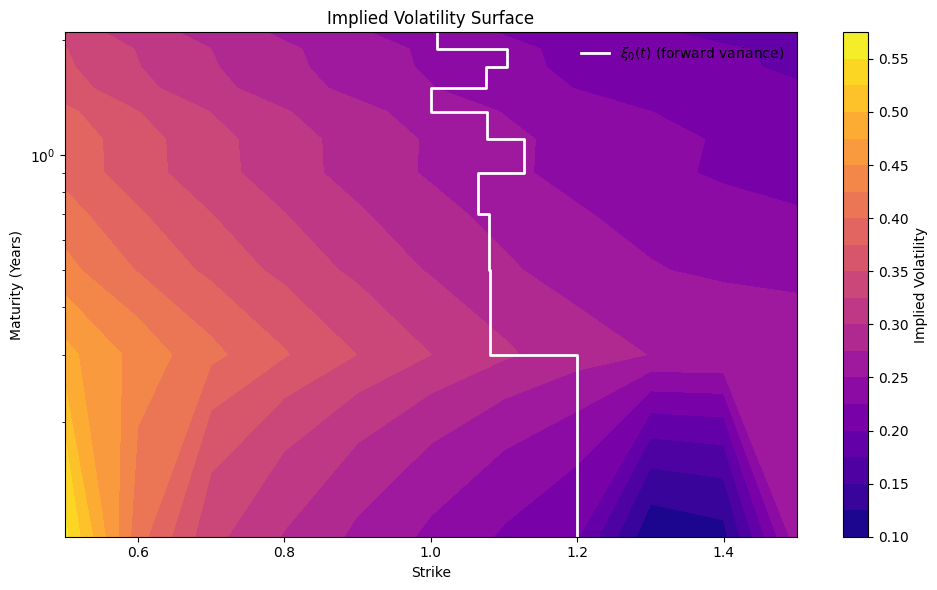

In [48]:
k = 239
x = surfaces[k]["iv_surface"]
xi0_knots = np.array(surfaces[k]["params"]["xi0_knots"])
maturities = np.array(surfaces[k]["grid"]["maturities"])
strikes = np.array(surfaces[k]["grid"]["strikes"])

# --- reconstruct bin edges for piecewise-constant ξ₀(t) ---
# first edge starts at 0, last one ends at the final maturity
edges = np.concatenate([[0.0], maturities])
x = repair_edges_local_directional(iv_surface=x, maturities=maturities, strikes=strikes)
plot_iv_surface(
    x, strikes, maturities,
    xi0_knots=xi0_knots,      # K values
    xi0_bin_edges=edges,      # K+1 edges
)



In [36]:

import numpy as np
from scipy.ndimage import convolve
def repair_edges_local_directional(iv_surface: np.ndarray,
                                   maturities: np.ndarray,
                                   strikes: np.ndarray,
                                   t_threshold: float = 0.35,
                                   dtype: np.dtype = np.float32,
                                   min_floor: float = 0.05) -> np.ndarray:
    """
    Lightweight, local edge stabilization for short maturities.
    - Fills NaNs row/col-wise.
    - Lifts left/right edges of short-maturity rows toward neighbors.
    - Smoothly replaces values < min_floor with weighted 3×3 Gaussian-style local mean.
    """
    iv = np.array(iv_surface, dtype=dtype, copy=True)
    nT, nK = iv.shape

    # --- Row-wise NaN fill
    for i in range(nT):
        row = iv[i]
        if np.any(np.isnan(row)):
            valid = ~np.isnan(row)
            if np.any(valid):
                iv[i] = np.interp(
                    np.arange(nK),
                    np.arange(nK)[valid],
                    row[valid],
                    left=row[valid][0],
                    right=row[valid][-1],
                )
            else:
                iv[i] = np.nan

    # --- Column-wise fill
    if np.isnan(iv).any():
        col_means = np.nanmean(iv, axis=0)
        for j in range(nK):
            nan_idx = np.isnan(iv[:, j])
            if np.any(nan_idx):
                iv[nan_idx, j] = col_means[j]
    iv = np.nan_to_num(iv, nan=np.nanmean(iv)).astype(dtype)

    # --- Directional edge correction for short maturities
# --- Directional edge lift for short maturities
    short_idx = np.where(maturities <= t_threshold)[0]
    for i in reversed(short_idx):
        row = iv[i]

        # ---- Left side: start from 3rd inner strike and move outward
        for j in range(2, -1, -1):  # indices [2, 1, 0]
            row[j] = max(row[j], row[j+1])

        # ---- Right side: start from 3rd inner strike from right and move outward
        for j in range(nK-3, nK):  # indices [nK-3, nK-2, nK-1]
            if j < nK-1:  # skip the last since j+1 would be out of bounds
                row[j+1] = max(row[j+1], row[j])

        iv[i] = row


    # --- Weighted local-mean correction for values < min_floor
    mask_rows = maturities <= 1000
    if np.any(mask_rows):
        iv_short = iv[mask_rows]

        # Gaussian-like kernel (center-heavy)
        kernel = np.array([[1, 2, 1],
                           [2, 4, 2],
                           [1, 2, 1]], dtype=np.float32)
        kernel /= kernel.sum()

        local_mean = convolve(iv_short, kernel, mode="reflect")

        mask_low = iv_short < min_floor
        iv_short[mask_low] = local_mean[mask_low]
        iv[mask_rows] = iv_short

    return iv.astype(dtype)

In [28]:
surfaces[k]["iv_surface"]

array([[0.35232872, 0.20059472, 0.30422708, 0.240141  , 0.20851731,
        0.18325835, 0.16052985, 0.1337127 , 0.06456117, 0.07080232,
        0.16321054],
       [0.35232872, 0.30679485, 0.27332965, 0.24440409, 0.21889846,
        0.19545032, 0.1750364 , 0.16086449, 0.15368578, 0.16270459,
        0.16321054],
       [0.35232872, 0.31707737, 0.28612   , 0.2582088 , 0.23322102,
        0.21019037, 0.19036794, 0.17627455, 0.16856328, 0.16521725,
        0.16321054],
       [0.36187118, 0.3262335 , 0.29579568, 0.26882064, 0.24388319,
        0.22182588, 0.2036202 , 0.18918894, 0.1800077 , 0.17681038,
        0.17631352],
       [0.3713781 , 0.33698887, 0.30682385, 0.28045985, 0.25646114,
        0.23534858, 0.21724756, 0.20264782, 0.19291012, 0.18806349,
        0.18664084],
       [0.3498756 , 0.31737164, 0.28943503, 0.26441035, 0.24238946,
        0.22296396, 0.20599921, 0.19266944, 0.18349847, 0.1791252 ,
        0.17795399],
       [0.36938348, 0.33674648, 0.30803707, 0.2825642 , 0.

In [20]:
train_surfaces = surfaces[:1400]
test_surfaces = surfaces[1400:]

train_loader, val_loader, bdim, Ks, Ts = DeepONet.prepare_data(train_surfaces)
model = DeepONet(branch_in_dim=bdim, latent_dim=64, hidden_dim=64, lr=1e-3)
model.set_grid(Ks, Ts)
model.set_io_dims(input_dim=bdim)
model.train_model(train_loader, val_loader, epochs=10)
fig = model.plot_evaluation(test_surfaces[0])  # no extra args needed
model.evaluate_and_save(test_surfaces, out_dir="deeponet_eval")


# ========================================
# 1️⃣ Prepare data
# ========================================
# train_loader, val_loader, input_dim, output_shape, Ks, Ts = MLP.prepare_data(train_surfaces)

# # ========================================
# # 2️⃣ Initialize model
# # ========================================
# model = MLP(
#     input_dim=input_dim,
#     output_shape=output_shape,
#     hidden_dims=(64, 64, 64),
#     lr=1e-3
# )

# # Save grid + dimensions internally (for plotting and saving)
# model.set_grid(Ks, Ts)
# model.set_io_dims(input_dim=input_dim, output_shape=output_shape)

# # ========================================
# # 3️⃣ Train
# # ========================================
# model.train_model(train_loader, val_loader, epochs=10)

# # ========================================
# # 4️⃣ Evaluate and plot
# # ========================================
# fig = model.plot_evaluation(test_surfaces[0])  # uses stored Ks, Ts
# x = model.evaluate(test_surfaces, out_dir="mlp_eval")


ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 14 and the array at index 510 has size 11

In [2]:
train_surfaces[0]

NameError: name 'train_surfaces' is not defined

# Consistency check 

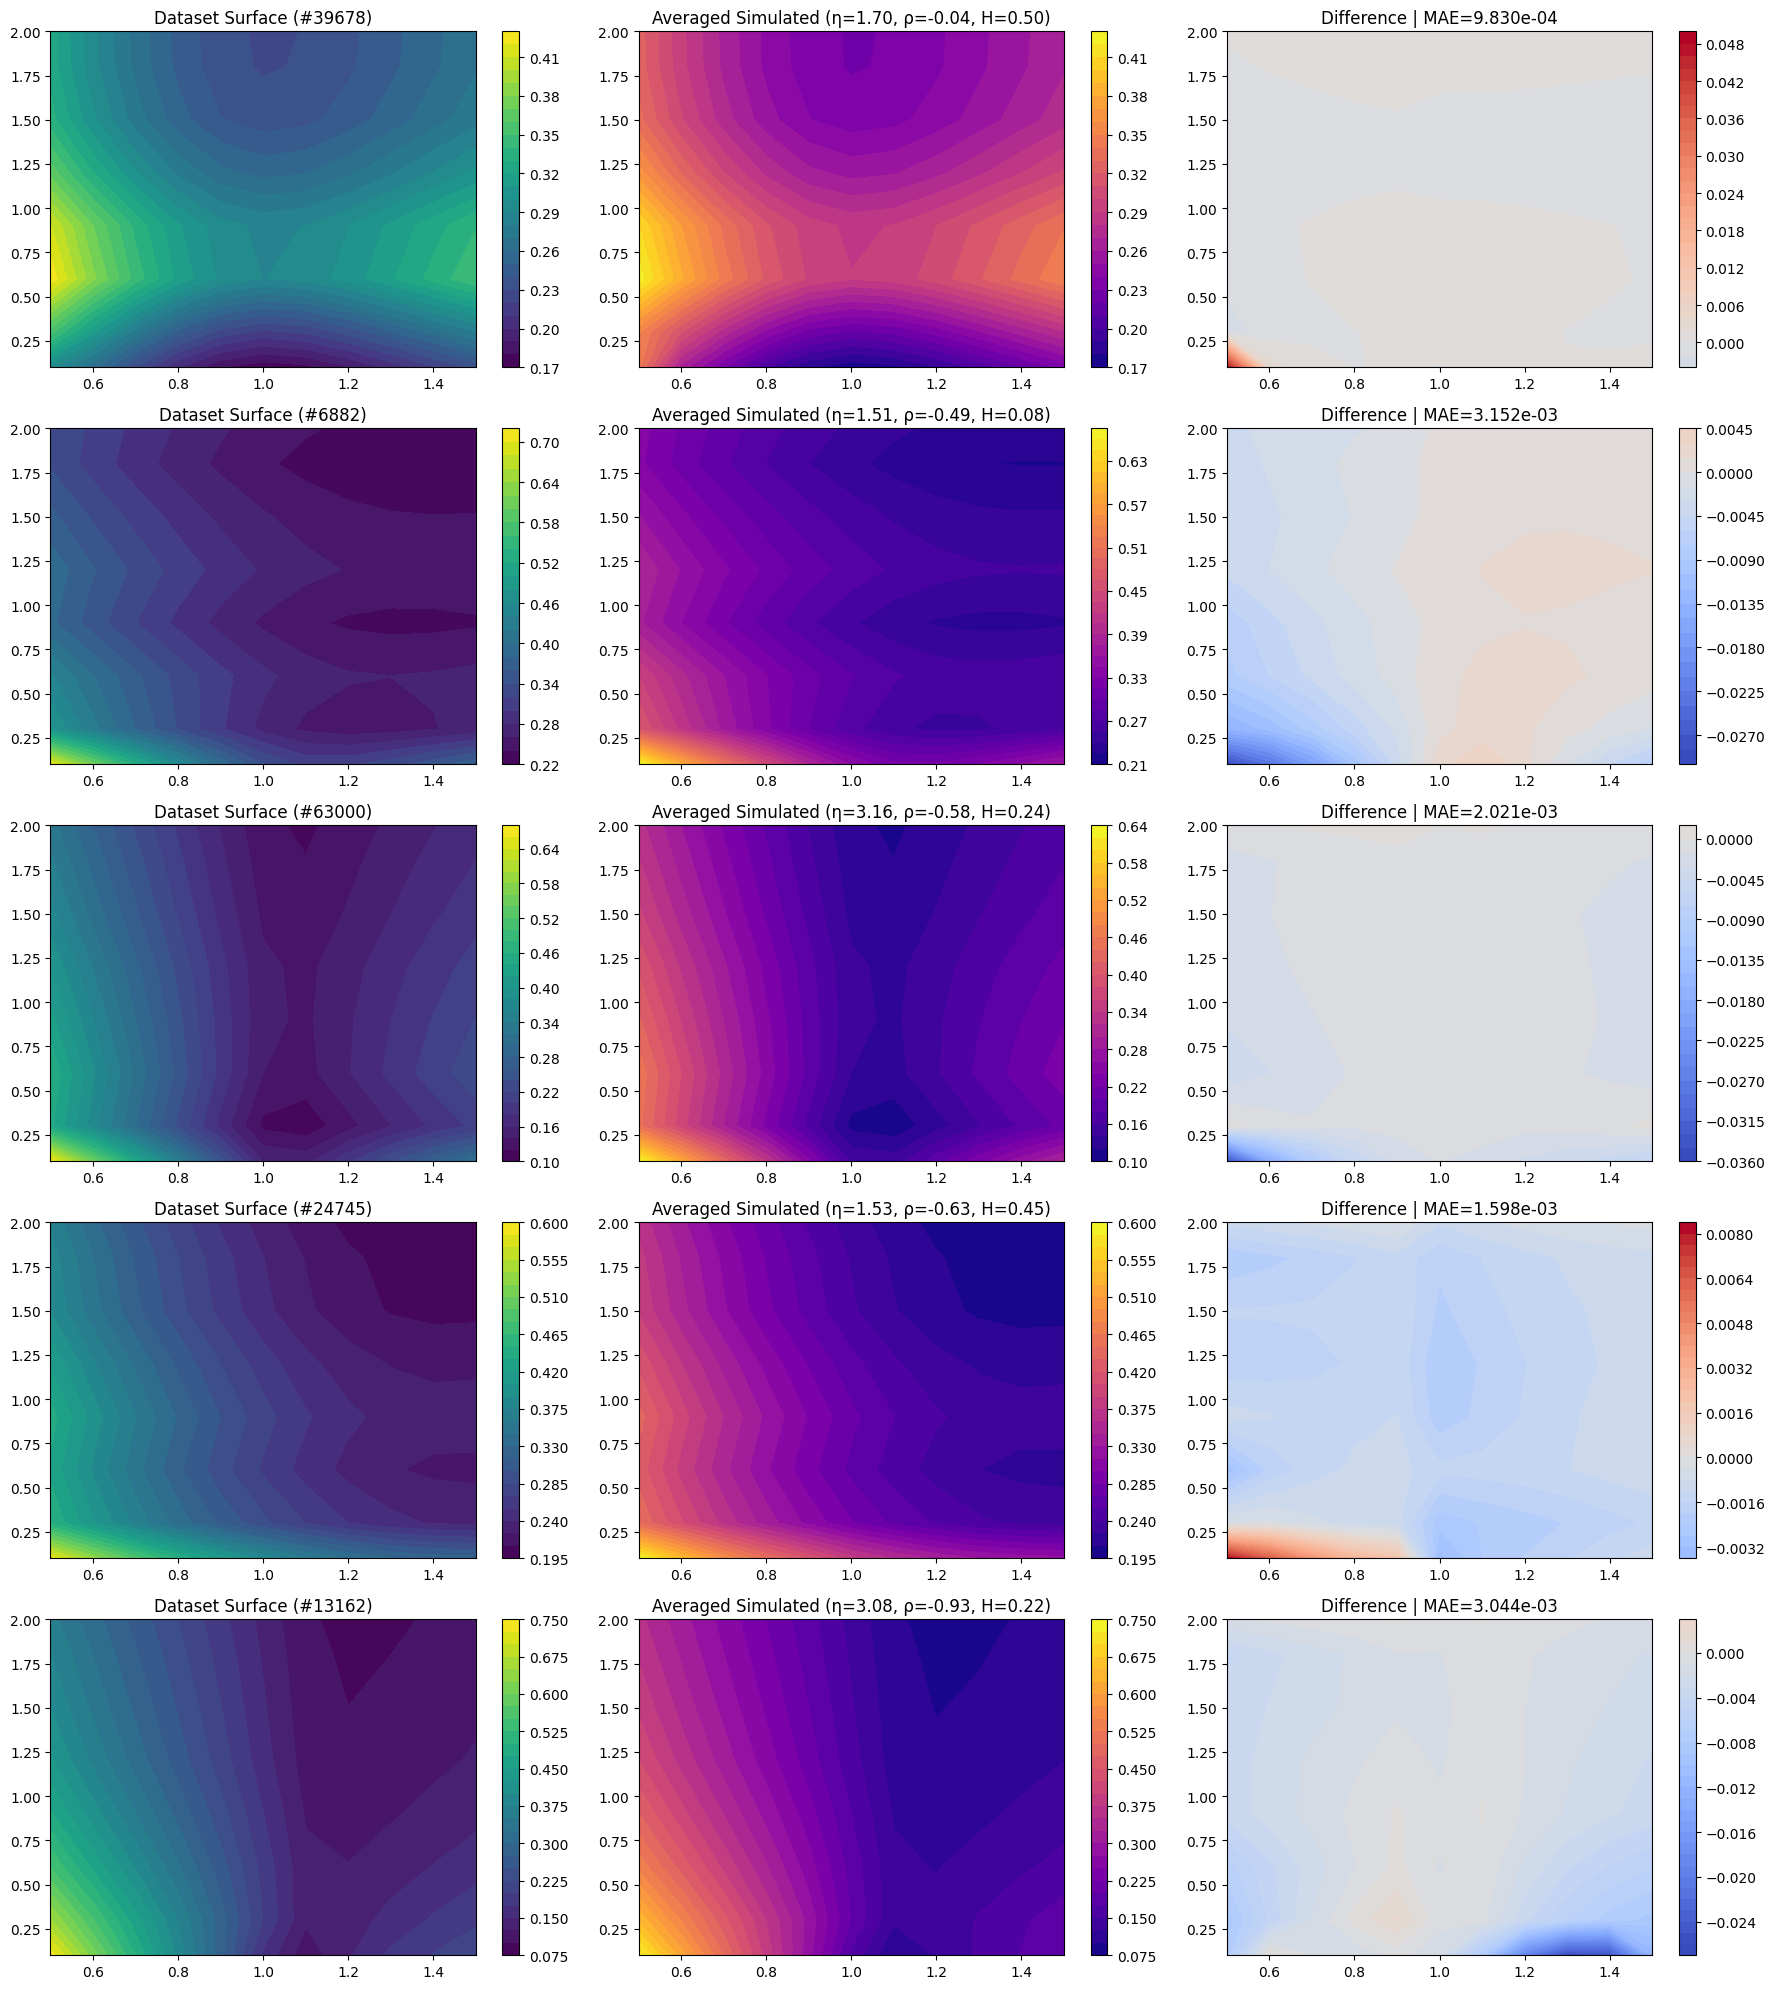

Comparison summary (averaged over seeds):
Idx 39678 | η=1.698, ρ=-0.039, H=0.499 | MAE=9.830e-04
Idx 6882 | η=1.514, ρ=-0.491, H=0.082 | MAE=3.152e-03
Idx 63000 | η=3.160, ρ=-0.576, H=0.244 | MAE=2.021e-03
Idx 24745 | η=1.529, ρ=-0.629, H=0.453 | MAE=1.598e-03
Idx 13162 | η=3.079, ρ=-0.927, H=0.223 | MAE=3.044e-03


In [4]:
import sys, os, gzip
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import matplotlib.pyplot as plt
from generation.surface_generation import generate_fixed_surface, SimulationConfig

# ======================================================
# 1️⃣ Load data
# ======================================================

f = gzip.GzipFile("../OriginalCode/TrainrBergomiTermStructure.txt.gz", "r")
dat = np.load(f)
xx = dat[:, :11]
yy = dat[:, 11:]

strikes = np.array([0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5])
maturities = np.array([0.1, 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.0])

cfg = SimulationConfig(M=50000, n=500, T_max=2.0, S0=1.0, G=1)

# ======================================================
# 2️⃣ Define subset of parameter sets to test
# ======================================================
num_tests = 5        # number of parameter combinations to test
num_seeds = 1        # how many seeds to average over
np.random.seed(12346)
test_indices = np.random.choice(len(xx), num_tests, replace=False)

# ======================================================
# 3️⃣ Run simulations and compare
# ======================================================
results = []
fig, axs = plt.subplots(num_tests, 3, figsize=(18, 4 * num_tests))
if num_tests == 1:
    axs = axs.reshape(1, -1)

for row, idx in enumerate(test_indices):
    xi0_knots = xx[idx, :8]
    eta, rho, H = xx[idx, 8:11]
    param_set = {"eta": float(eta), "rho": float(rho), "H": float(H)}

    # Average several random seeds
    sim_surfaces = []
    for s in range(num_seeds):
        seed_val = 400 + s * 17  # any deterministic spacing
        surf = generate_fixed_surface(param_set, xi0_knots, strikes, maturities, cfg, seed=seed_val)
        sim_surfaces.append(surf["iv_surface"])
    sim_surface = np.mean(sim_surfaces, axis=0)

    # True dataset surface
    true_surface = yy[idx].reshape(len(maturities), len(strikes))

    diff = sim_surface - true_surface
    mae = np.mean(np.abs(diff))
    results.append({"idx": idx, "eta": eta, "rho": rho, "H": H, "mae": mae})

    K, T = np.meshgrid(strikes, maturities)

    # Plot
    c0 = axs[row, 0].contourf(K, T, true_surface, levels=30, cmap="viridis")
    axs[row, 0].set_title(f"Dataset Surface (#{idx})")
    plt.colorbar(c0, ax=axs[row, 0])

    c1 = axs[row, 1].contourf(K, T, sim_surface, levels=30, cmap="plasma")
    axs[row, 1].set_title(f"Averaged Simulated (η={eta:.2f}, ρ={rho:.2f}, H={H:.2f})")
    plt.colorbar(c1, ax=axs[row, 1])

    vmax = np.max(np.abs(diff))
    c2 = axs[row, 2].contourf(K, T, diff, levels=30, cmap="coolwarm", vmin=-vmax, vmax=vmax)
    axs[row, 2].set_title(f"Difference | MAE={mae:.3e}")
    plt.colorbar(c2, ax=axs[row, 2])

plt.tight_layout()
plt.show()

# ======================================================
# 4️⃣ Print summary stats
# ======================================================
print("Comparison summary (averaged over seeds):")
for r in results:
    print(f"Idx {r['idx']:>4} | η={r['eta']:.3f}, ρ={r['rho']:.3f}, H={r['H']:.3f} | MAE={r['mae']:.3e}")


# MC Noise estimation

In [10]:
def plot_simulation_noise_heatmap(param_set, xi0_knots, strikes, maturities, cfg,
                                  num_repeats=5, seed_base=1000, figsize=(6,5), levels=30):
    """
    Re-simulates the same parameter world multiple times and visualizes the
    pointwise absolute difference (Monte Carlo noise) as a heatmap.

    Each cell (T,K) shows the mean absolute deviation of IV across repeated MC runs.
    """
    # --- Generate surfaces for identical parameters ---
    surfaces = []
    for i in range(num_repeats):
        seed_val = seed_base + 37 * i
        surf = generate_fixed_surface(param_set, xi0_knots, strikes, maturities, cfg, seed=seed_val)
        surfaces.append(surf["iv_surface"])
    surfaces = np.stack(surfaces, axis=0)  # (num_repeats, nT, nK)

    # --- Compute pairwise absolute differences ---
    nR = num_repeats
    abs_diffs = np.zeros_like(surfaces[0])
    count = 0
    for i in range(nR):
        for j in range(i+1, nR):
            abs_diffs += np.abs(surfaces[i] - surfaces[j])
            count += 1
    abs_diffs /= count

    # --- Plot ---
    K, T = np.meshgrid(strikes, maturities)
    fig, ax = plt.subplots(figsize=figsize)
    c = ax.contourf(K, T, abs_diffs, levels=levels, cmap="inferno")
    plt.colorbar(c, ax=ax, label="Mean |ΔIV| across MC runs")
    ax.set_title(f"Monte Carlo Noise Heatmap ({num_repeats} runs)")
    ax.set_xlabel("Strike")
    ax.set_ylabel("Maturity")

    # Print global stats
    mean_mae = np.mean(abs_diffs)
    print(f"Global noise floor (mean abs diff): {mean_mae:.4e}")

    return fig, abs_diffs



Global noise floor (mean abs diff): 2.3603e-03


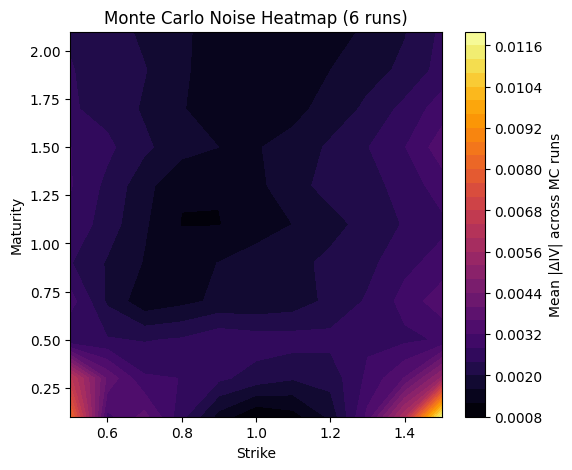

In [14]:
from generation.surface_generation import generate_fixed_surface
import matplotlib.pyplot as plt
# Define fixed grid
strikes = np.array([0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5])
maturities = np.array([0.1, 0.3, 0.5, 0.7, 0.9, 1.1, 1.3, 1.5, 1.7, 1.9, 2.1])

# Example parameter set
param_set = {"eta": 2.5, "rho": -0.6, "H": 0.05}

# Choose same number of xi₀ knots as maturities
rng = np.random.default_rng(42)
xi0_knots = rng.uniform(0.01, 0.16, size=len(maturities))

# Plot Monte-Carlo noise heatmap
fig, noise_map = plot_simulation_noise_heatmap(
    param_set=param_set,
    xi0_knots=xi0_knots,
    strikes=strikes,
    maturities=maturities,
    cfg=cfg,               # your SimulationConfig
    num_repeats=6,
    seed_base=1234
)
plt.show()
